# Smart Lender

This notebook performs initial dataset verification and exploratory data analysis for the Smart Lender machine learning project.

It does not preprocess the data, encode features, or train any machine learning model.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load Dataset

In [2]:
from pathlib import Path

data_path = Path("../data/loan_prediction.csv")
df = pd.read_csv(data_path)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Dataset Overview

In [3]:
display(df.head())
display(df.tail())
print(f"Dataset Shape: {df.shape}")

display(pd.DataFrame({"Column Name": df.columns, "Data Type": df.dtypes.astype(str).values}))
df.info()
display(df.describe(include="all").transpose())
display(df.isnull().sum().to_frame(name="Missing Values"))
print(f"Duplicate Records Count: {df.duplicated().sum()}")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


Dataset Shape: (614, 13)


,Column Name,Data Type
0,Loan_ID,object
1,Gender,object
2,Married,object
3,Dependents,object
4,Education,object
5,Self_Employed,object
6,ApplicantIncome,int64
7,CoapplicantIncome,float64
8,LoanAmount,float64
9,Loan_Amount_Term,float64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


,Missing Values
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


Duplicate Records Count: 0


## 4. Data Exploration

In [4]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

unique_rows = []
for col in categorical_columns:
    values = df[col].dropna().unique().tolist()
    unique_rows.append(
        {
            "Column": col,
            "Unique Count": len(values),
            "Unique Values": values if len(values) <= 10 else values[:10] + ["..."]
        }
    )

unique_values_df = pd.DataFrame(unique_rows)
display(unique_values_df)

,Column,Unique Count,Unique Values
0,Loan_ID,614,"[LP001002, LP001003, LP001005, LP001006, LP001..."
1,Gender,2,"[Male, Female]"
2,Married,2,"[No, Yes]"
3,Dependents,4,"[0, 1, 2, 3+]"
4,Education,2,"[Graduate, Not Graduate]"
5,Self_Employed,2,"[No, Yes]"
6,Property_Area,3,"[Urban, Rural, Semiurban]"
7,Loan_Status,2,"[Y, N]"


## 5. Data Visualization

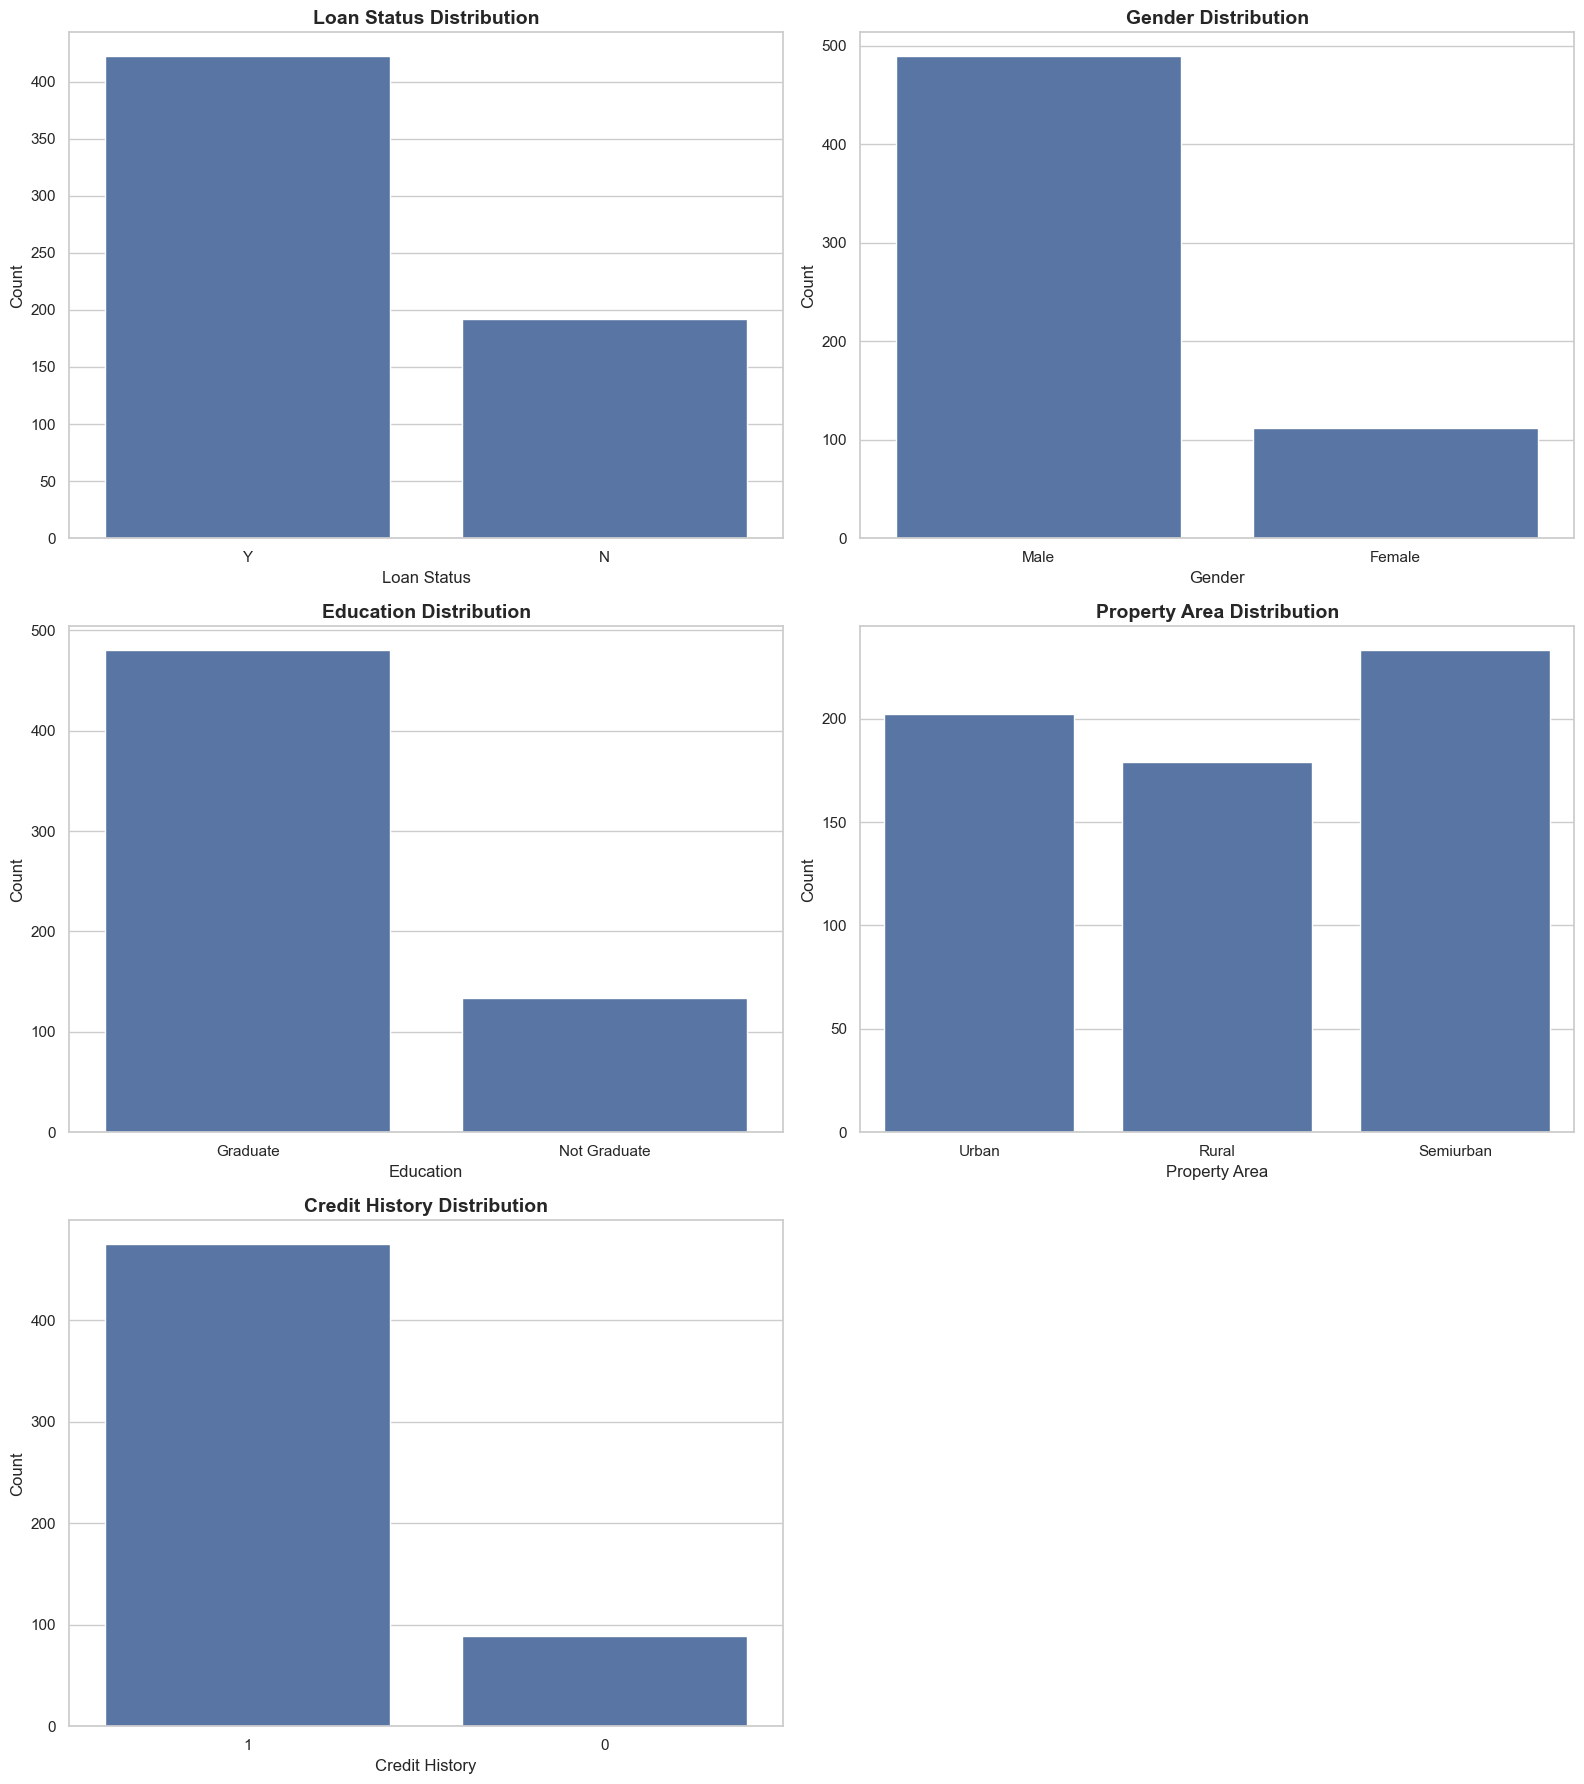

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

plot_specs = [
    ("Loan_Status", "Loan Status Distribution", "Loan Status"),
    ("Gender", "Gender Distribution", "Gender"),
    ("Education", "Education Distribution", "Education"),
    ("Property_Area", "Property Area Distribution", "Property Area"),
    ("Credit_History", "Credit History Distribution", "Credit History"),
]

for ax, (column, title, xlabel) in zip(axes, plot_specs):
    plot_data = df.dropna(subset=[column]).copy()
    if column == "Credit_History":
        plot_data[column] = plot_data[column].astype("Int64").astype(str)
    sns.countplot(data=plot_data, x=column, ax=ax)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 6. Key Observations

## 7. Data Preprocessing

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

processed_df = df.copy()
processed_df = processed_df.drop(columns=["Loan_ID"])

categorical_cols = processed_df.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = processed_df.select_dtypes(include=["number"]).columns.tolist()

for col in categorical_cols:
    processed_df[col] = processed_df[col].fillna(processed_df[col].mode(dropna=True)[0])

for col in numerical_cols:
    processed_df[col] = processed_df[col].fillna(processed_df[col].median())

print(f"Missing values handled: {processed_df.isnull().sum().sum() == 0}")

processed_df["Loan_Status"] = processed_df["Loan_Status"].map({"Y": 1, "N": 0})

X = processed_df.drop(columns=["Loan_Status"])
y = processed_df["Loan_Status"]
X_encoded = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

feature_df = pd.DataFrame({"Feature Name": X_encoded.columns})
summary_df = pd.DataFrame(
    {
        "Metric": ["X_train shape", "X_test shape", "Encoded feature count"],
        "Value": [str(X_train.shape), str(X_test.shape), X_encoded.shape[1]],
    }
)

print(f"Number of encoded features: {X_encoded.shape[1]}")
display(summary_df)
display(feature_df)
display(processed_df.head())

Missing values handled: True
Number of encoded features: 20


,Metric,Value
0,X_train shape,"(491, 20)"
1,X_test shape,"(123, 20)"
2,Encoded feature count,20


,Feature Name
0,ApplicantIncome
1,CoapplicantIncome
2,LoanAmount
3,Loan_Amount_Term
4,Credit_History
5,Gender_Female
6,Gender_Male
7,Married_No
8,Married_Yes
9,Dependents_0


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


## 8. Model Building and Evaluation

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

trained_models = {}
predictions = {}
model_results = []

def train_and_evaluate_model(model, x_train, x_test, y_train, y_test, model_name):
    model.fit(x_train, y_train)
    train_predictions = model.predict(x_train)
    test_predictions = model.predict(x_test)
    test_probabilities = model.predict_proba(x_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Train Accuracy": round(accuracy_score(y_train, train_predictions), 4),
        "Test Accuracy": round(accuracy_score(y_test, test_predictions), 4),
        "Precision": round(precision_score(y_test, test_predictions, zero_division=0), 4),
        "Recall": round(recall_score(y_test, test_predictions, zero_division=0), 4),
        "F1 Score": round(f1_score(y_test, test_predictions, zero_division=0), 4),
        "ROC-AUC Score": round(roc_auc_score(y_test, test_probabilities), 4),
    }

    return {
        "trained_model": model,
        "train_predictions": train_predictions,
        "test_predictions": test_predictions,
        "metrics": metrics,
    }

model_configs = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42), X_train_scaled, X_test_scaled),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), X_train, X_test),
    ("Random Forest", RandomForestClassifier(random_state=42), X_train, X_test),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42), X_train, X_test),
    ("XGBoost", XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric="logloss"), X_train, X_test),
]

for model_name, model, x_train_data, x_test_data in model_configs:
    evaluation = train_and_evaluate_model(
        model,
        x_train_data,
        x_test_data,
        y_train,
        y_test,
        model_name,
    )
    trained_models[model_name] = evaluation["trained_model"]
    predictions[model_name] = {
        "train": evaluation["train_predictions"],
        "test": evaluation["test_predictions"],
    }
    model_results.append(evaluation["metrics"])

comparison_df = pd.DataFrame(model_results)[["Model", "Train Accuracy", "Test Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC Score"]].sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
best_model_df = comparison_df.loc[[0], ["Model", "Test Accuracy"]]

def highlight_best_row(row):
    return ["background-color: #d9ead3; font-weight: bold" if row.name == 0 else "" for _ in row]

display(comparison_df.style.apply(highlight_best_row, axis=1) if hasattr(comparison_df, "style") else comparison_df)
display(best_model_df)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
0,Logistic Regression,0.818700,0.788600,0.759600,0.987500,0.858700,0.749700
1,Gradient Boosting,0.894100,0.772400,0.754900,0.962500,0.846200,0.693600
2,Random Forest,1.000000,0.764200,0.757600,0.937500,0.838000,0.743600
3,K-Nearest Neighbors,0.800400,0.756100,0.740400,0.962500,0.837000,0.720100
4,XGBoost,0.987800,0.756100,0.750000,0.937500,0.833300,0.749100
5,Decision Tree,1.000000,0.715400,0.758600,0.825000,0.790400,0.668300


,Model,Test Accuracy
0,Logistic Regression,0.7886


## 9. Model Persistence

In [ ]:
from datetime import datetime
from pathlib import Path
import json
import pickle

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

if best_model_name not in trained_models:
    raise KeyError(f"Best model '{best_model_name}' not found in trained_models.")

best_model = trained_models[best_model_name]
requires_scaling = best_model_name in {"Logistic Regression", "K-Nearest Neighbors"}

feature_names = X_encoded.columns.tolist()
saved_files = []

try:
    model_path = models_dir / "best_model.pkl"
    feature_path = models_dir / "feature_names.pkl"
    metadata_path = models_dir / "model_metadata.json"
    scaler_path = models_dir / "scaler.pkl"

    with model_path.open("wb") as file:
        pickle.dump(best_model, file)
    saved_files.append(model_path)

    with feature_path.open("wb") as file:
        pickle.dump(feature_names, file)
    saved_files.append(feature_path)

    if requires_scaling:
        with scaler_path.open("wb") as file:
            pickle.dump(scaler, file)
        saved_files.append(scaler_path)

    best_row = comparison_df.loc[comparison_df["Model"] == best_model_name].iloc[0]
    metadata = {
        "Best Model Name": best_model_name,
        "Train Accuracy": best_row["Train Accuracy"],
        "Test Accuracy": best_row["Test Accuracy"],
        "Precision": best_row["Precision"],
        "Recall": best_row["Recall"],
        "F1 Score": best_row["F1 Score"],
        "ROC-AUC Score": best_row["ROC-AUC Score"],
        "Total Features": len(feature_names),
        "Feature Names": feature_names,
        "Timestamp": datetime.now().isoformat(timespec="seconds"),
    }

    with metadata_path.open("w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=4)
    saved_files.append(metadata_path)

    verification_df = pd.DataFrame([
        {"File Name": file_path.name, "Status": "Created" if file_path.exists() else "Missing", "Location": str(file_path.resolve())} for file_path in saved_files
    ])

    success_summary = pd.DataFrame([
        {
            "Best Model": best_model_name,
            "Saved Files": "best_model.pkl, feature_names.pkl, scaler.pkl (if used), model_metadata.json",
            "Save Location": str(models_dir.resolve()),
        }
    ])

    display(success_summary)
    display(verification_df)

except Exception as error:
    raise RuntimeError(f"Model persistence failed: {error}") from error

,Best Model,Saved Files,Save Location
0,Logistic Regression,", best_model.pkl, feature_names.pkl, scaler.pk...",C:\SANJU\OneDrive\Documents\phase\projects\pro...


,File Name,Status,Location
0,best_model.pkl,Created,C:\SANJU\OneDrive\Documents\phase\projects\pro...
1,feature_names.pkl,Created,C:\SANJU\OneDrive\Documents\phase\projects\pro...
2,scaler.pkl,Created,C:\SANJU\OneDrive\Documents\phase\projects\pro...
3,model_metadata.json,Created,C:\SANJU\OneDrive\Documents\phase\projects\pro...
